# EEG Clasificación de Predisposición al Alcoholismo

Durante el desarrollo de este proyecto, nos enfrentamos a diversos desafíos relacionados con el sobreajuste y el sesgo de los modelos. En varias etapas, los clasificadores predecían únicamente una clase (todos ceros o todos unos), lo cual evidenció una falta de generalización. 

Para mitigar estos problemas, implementamos técnicas de preprocesamiento como la normalización y el balanceo de clases usando SMOTE. También desarrollamos desde cero los modelos de regresión logística y máquinas de vectores de soporte (SVM), ajustando hiperparámetros cuidadosamente.

Se utilizó la biblioteca TSFresh para extraer características relevantes de las señales EEG. No obstante, el uso de configuraciones más completas como `ComprehensiveFCParameters` o `EfficientFCParameters` no fue viable computacionalmente, ya que el tiempo de ejecución superaba las 6 horas. Por ello, se optó por `MinimalFCParameters`.

Pese a las dificultades, se logró generar predicciones válidas sobre el conjunto de test y cumplir los objetivos mínimos del proyecto, aunque hay espacio significativo para mejorar.


In [1]:
'''!pip install -r reqs.txt'''

'!pip install -r reqs.txt'

## 0. Importar y copiar archivos


In [2]:
import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils import resample

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.decomposition import PCA


from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, EfficientFCParameters, MinimalFCParameters
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split




# 1. Carga de datos HDF5

Se cargan los archivos `train.h5` y `test.h5`, que contienen los datos EEG para entrenamiento y test.



In [3]:
with h5py.File('train.h5', 'r') as f:
    X_train = np.array(f['x'])
    y_train = np.array(f['y'])

with h5py.File('test.h5', 'r') as f:
    x_test = np.array(f['x'])

In [4]:
X_train.shape, y_train.shape

((204, 1, 18530), (204,))

In [5]:
x_train_df = pd.DataFrame(X_train[:,0,:])
y_train_df = pd.Series(y_train)

In [6]:
x_train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,18520,18521,18522,18523,18524,18525,18526,18527,18528,18529
0,-0.005859,-0.011414,-0.010773,-0.010559,-0.008850,-0.008636,-0.009094,-0.008850,-0.009369,-0.009888,...,0.012573,0.007721,0.002075,-0.003174,-0.007843,-0.012573,-0.017670,-0.019897,-0.021637,-0.018860
1,0.002380,0.005127,0.005737,0.007263,0.008575,0.010742,0.012970,0.017212,0.022003,0.027954,...,0.003815,0.005707,0.006683,0.006012,0.003601,0.000427,-0.001984,-0.003998,-0.005981,-0.007660
2,0.058075,0.122040,0.108307,0.113769,0.105316,0.103912,0.094849,0.091187,0.080170,0.074432,...,-0.009613,-0.008301,-0.005402,-0.007690,-0.006592,-0.007904,-0.009674,-0.013153,-0.014130,-0.018250
3,-0.007385,-0.011932,-0.004700,-0.003143,0.005493,0.006744,0.012085,0.012909,0.018097,0.021606,...,-0.003082,-0.007050,-0.010956,-0.013916,-0.017944,-0.019867,-0.025604,-0.027161,-0.030273,-0.039368
4,-0.000458,-0.001099,0.003723,0.002930,0.004059,0.003906,0.003265,0.002777,0.000488,-0.001221,...,0.040039,0.040680,0.041901,0.040710,0.038727,0.025818,0.019470,0.010010,0.004242,0.003235


In [7]:
y_train_df.head()


0    0
1    1
2    0
3    0
4    0
dtype: int64

In [8]:
x_train_df.describe()


,0,1,2,3,4,5,6,7,8,9,...,18520,18521,18522,18523,18524,18525,18526,18527,18528,18529
count,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,...,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,0.008415,0.012437,0.011228,0.013297,0.009373,0.011520,0.010013,0.007456,0.010405,0.007833,...,0.002991,0.003326,0.002490,0.002363,0.002087,0.001859,0.001159,0.000616,-0.000670,-0.001832
std,0.062386,0.133863,0.113886,0.114217,0.103722,0.093394,0.082969,0.081629,0.078379,0.076676,...,0.048276,0.049741,0.052047,0.053149,0.052574,0.052996,0.053340,0.054319,0.058060,0.063040
min,-0.100464,-0.653076,-0.577881,-0.361969,-0.336578,-0.250702,-0.203522,-0.319641,-0.215271,-0.252319,...,-0.284821,-0.277618,-0.294800,-0.303314,-0.309082,-0.314179,-0.310944,-0.314697,-0.355682,-0.428650
25%,-0.005814,-0.011681,-0.009956,-0.011040,-0.011177,-0.011909,-0.011658,-0.012260,-0.012589,-0.011971,...,-0.009186,-0.009445,-0.009949,-0.009804,-0.010498,-0.010292,-0.009491,-0.009811,-0.009834,-0.010048
50%,0.000336,0.000641,0.000732,0.001541,0.000854,0.001007,0.000610,-0.000076,0.000137,-0.000275,...,0.000778,0.001007,0.000183,-0.000198,-0.000519,-0.000580,-0.000153,-0.000427,-0.000595,-0.000214
75%,0.006386,0.013466,0.013130,0.014404,0.011749,0.012032,0.012276,0.011971,0.012863,0.013062,...,0.015312,0.015869,0.013893,0.013741,0.014389,0.015167,0.012947,0.011543,0.011566,0.011856
max,0.508087,0.999969,0.887634,0.943298,0.844208,0.851410,0.814331,0.807312,0.780212,0.769196,...,0.273468,0.304779,0.328979,0.344208,0.350464,0.356995,0.357971,0.356659,0.353302,0.348450


# 2. Visualización de algunas señales EEG
Se grafican señales EEG individuales para observar patrones visibles entre clases.


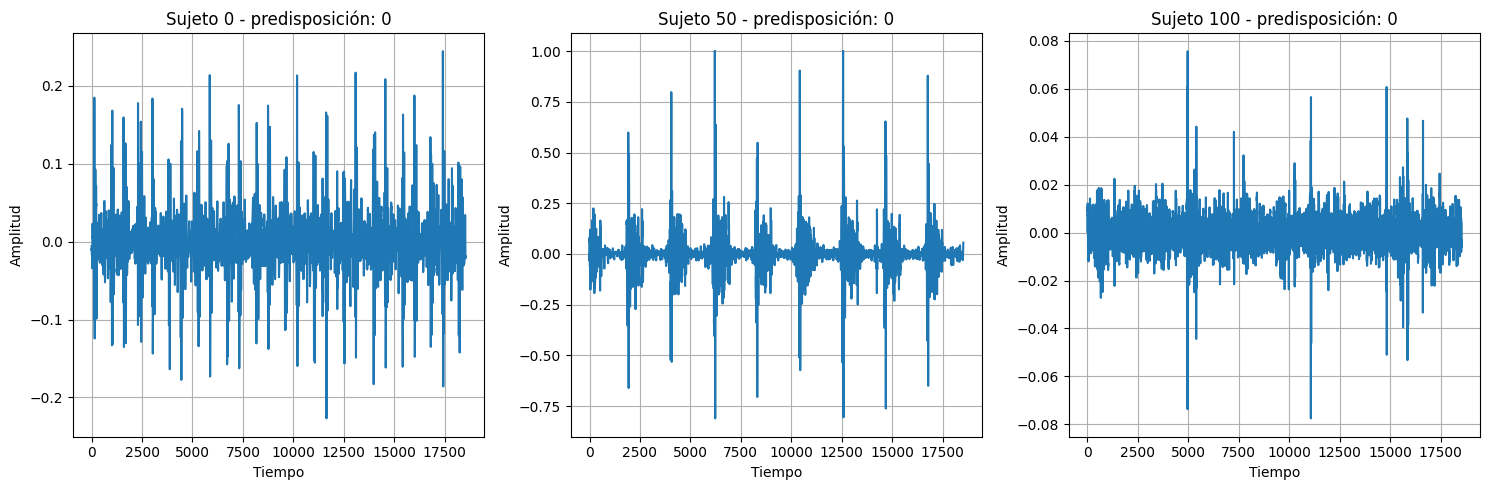

In [9]:
indices = [0, 50, 100]
plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 3, i + 1)
    plt.plot(X_train[idx][0])
    plt.title(f'Sujeto {idx} - predisposición: {y_train[idx]}')
    plt.xlabel('Tiempo')
    plt.ylabel('Amplitud')
    plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Análisis y limpieza
Se realiza un análisis preliminar de las clases, presencia de valores nulos, outliers y estadísticas básicas de las señales.


Distribución de clases:


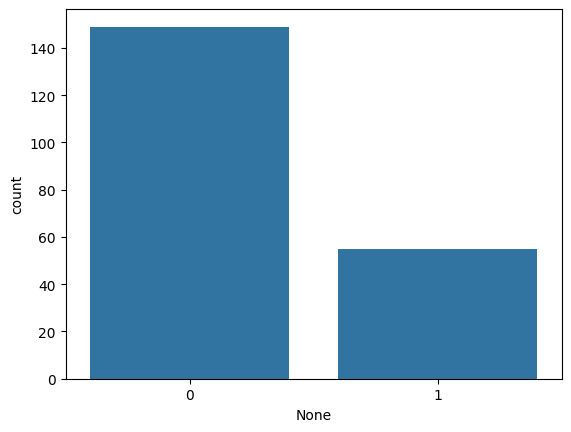

Valores faltantes o infinitos:
False False


In [10]:
print("Distribución de clases:")
sns.countplot(x=pd.Series(y_train))
plt.show()

print("Valores faltantes o infinitos:")
print(np.any(np.isnan(X_train)), np.any(np.isinf(X_train)))

In [11]:
print(f"¿Hay valores NaN en X_train?: {np.any(np.isnan(X_train))}")
print(f"¿Hay valores infinitos en X_train?: {np.any(np.isinf(X_train))}")
print(f"¿Hay valores NaN en y_train?: {np.any(np.isnan(y_train))}")
print(f"¿Hay valores infinitos en y_train?: {np.any(np.isinf(y_train))}")
print(f"Rango de valores en X_train: {np.min(X_train)}, {np.max(X_train)}")
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
std_dev = np.std(X_train)
variance = np.var(X_train)

print(f"Desviación estándar: {std_dev}")
print(f"Varianza: {variance}")


¿Hay valores NaN en X_train?: False
¿Hay valores infinitos en X_train?: False
¿Hay valores NaN en y_train?: False
¿Hay valores infinitos en y_train?: False
Rango de valores en X_train: -1.0, 0.9999695
Forma de X_train: (204, 1, 18530)
Forma de y_train: (204,)
Desviación estándar: 0.07511160078845772
Varianza: 0.005641752573004643


# 4. Normalización
Se aplica normalización estándar (`StandardScaler`) a todas las señales EEG para igualar la escala de los valores en todos los canales y tiempos.


In [12]:
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
x_test_norm = scaler.transform(x_test.reshape(x_test.shape[0], -1)).reshape(x_test.shape)

In [13]:
print(f"Media después de normalizar: {np.mean(X_train_norm):.2f}")
print(f"Desviación estándar después de normalizar: {np.std(X_train_norm):.2f}")

Media después de normalizar: -0.00
Desviación estándar después de normalizar: 1.00


In [14]:
print(f"Media después de normalizar: {np.mean(x_test_norm):.2f}")
print(f"Desviación estándar después de normalizar: {np.std(x_test_norm):.2f}")

Media después de normalizar: 0.00
Desviación estándar después de normalizar: 1.01


# 5. Extracción de características con TSFresh
Se emplea `tsfresh.extract_features` con `MinimalFCParameters` para generar características temporales relevantes por cada canal y sujeto. El dataframe generado tiene una fila por sujeto y múltiples columnas que representan distintas estadísticas temporales.



In [15]:
n_samples, n_channels, n_timesteps = X_train_norm.shape

data = pd.DataFrame({
    'id': np.repeat(np.arange(n_samples), n_timesteps * n_channels),
    'time': np.tile(np.arange(n_timesteps), n_samples * n_channels),
    'value': X_train_norm.reshape(-1),
    'channel': np.tile(np.repeat(np.arange(n_channels), n_timesteps), n_samples)
})

data_test = pd.DataFrame({
    'id': np.repeat(np.arange(x_test.shape[0]), n_timesteps * n_channels),
    'time': np.tile(np.arange(n_timesteps), x_test.shape[0] * n_channels),
    'value': x_test_norm.reshape(-1),
    'channel': np.tile(np.repeat(np.arange(n_channels), n_timesteps), x_test.shape[0])
})

params = MinimalFCParameters()
features = extract_features(data, column_id='id', column_sort='time', column_kind='channel', column_value='value', default_fc_parameters=params)
features_test = extract_features(data_test, column_id='id', column_sort='time', column_kind='channel', column_value='value', default_fc_parameters=params)


Feature Extraction: 100%|██████████| 41/41 [00:00<00:00, 77.80it/s]


In [16]:
print(f"Tamaño del DataFrame: {data.shape}")

Tamaño del DataFrame: (3780120, 4)


In [17]:
print(f"Tamaño del DataFrame: {data_test.shape}")

Tamaño del DataFrame: (3798650, 4)


# 6. División y balanceo de datos
Se divide el conjunto de entrenamiento en datos para entrenamiento y validación utilizando `train_test_split`.



Se utiliza `SMOTE` para balancear las clases en el conjunto de entrenamiento, generando ejemplos sintéticos de la clase minoritaria.


In [ ]:

X_train_split, X_val, y_train_split, y_val = train_test_split(
    features, y_train, test_size=0.3, random_state=42
)
###este es mejor con logistic
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_split, y_train_split)

print(f"Nueva distribución de clases: {pd.Series(y_train_bal).value_counts()}")


'''from imblearn.under_sampling import NearMiss
###este es mejor con sns
near_miss = NearMiss(sampling_strategy='auto')
X_train_bal, y_train_bal = near_miss.fit_resample(X_train_split, y_train_split)

print(f"Nueva distribución de clases: {pd.Series(y_train_bal).value_counts()}")
print(f"Datos de entrenamiento: {X_train_split.shape}, Datos de validación: {X_val.shape}")
smote = SMOTE(random_state=42)'''

#otras opciones
'''
X_train_bal, y_train_bal = smote.fit_resample(X_train_split, y_train_split)

print("Nueva distribución de clases en el conjunto de entrenamiento (SMOTE):")
print(pd.Series(y_train_bal).value_counts())

from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(sampling_strategy='auto', random_state=42)
X_train_bal, y_train_bal = smote_enn.fit_resample(X_train_split, y_train_split)

print(f"Nueva distribución de clases: {pd.Series(y_train_bal).value_counts()}")'''


Nueva distribución de clases: 0    39
1    39
Name: count, dtype: int64


'\nX_train_bal, y_train_bal = smote.fit_resample(X_train_split, y_train_split)\n\nprint("Nueva distribución de clases en el conjunto de entrenamiento (SMOTE):")\nprint(pd.Series(y_train_bal).value_counts())\n\nfrom imblearn.combine import SMOTEENN\n\nsmote_enn = SMOTEENN(sampling_strategy=\'auto\', random_state=42)\nX_train_bal, y_train_bal = smote_enn.fit_resample(X_train_split, y_train_split)\n\nprint(f"Nueva distribución de clases: {pd.Series(y_train_bal).value_counts()}")'

# 7 Entrenamiento de modelos


## 7.1 Regresión Logística desde cero


In [19]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def logistic_regression(X, y, lr=0.5, epochs=10000, class_weights=None, regularization=0.01):
    n_samples, n_features = X.shape
    w = np.random.uniform(-0.1, 0.1, size=n_features)  
    b = 0 

    if class_weights is None:
        class_weights = np.ones_like(y)

    for epoch in range(epochs):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        error = y_pred - y
        dw = (np.dot(X.T, error * class_weights) / n_samples) + (regularization * w)
        db = np.sum(error * class_weights) / n_samples

        w -= lr * dw
        b -= lr * db

    return w, b

def predict_logistic(X, w, b, threshold=0.5):
    probabilities = sigmoid(np.dot(X, w) + b)
    return (probabilities >= threshold).astype(int)

def compute_class_weights(y):
    class_counts = np.bincount(y)
    total_samples = len(y)
    weights = total_samples / (len(class_counts) * class_counts)
    return weights[y]

scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_bal)
X_val_np = scaler.transform(X_val)

class_weights = compute_class_weights(y_train_bal)

w, b = logistic_regression(X_train_np, y_train_bal, lr=0.1, epochs=5000, class_weights=class_weights, regularization=0.01)

y_val_pred = predict_logistic(X_val_np, w, b)

print("Evaluación de Regresión Logística:")
print(classification_report(y_val, y_val_pred))

Evaluación de Regresión Logística:
              precision    recall  f1-score   support

           0       0.84      0.67      0.75        46
           1       0.40      0.62      0.49        16

    accuracy                           0.66        62
   macro avg       0.62      0.65      0.62        62
weighted avg       0.72      0.66      0.68        62



In [20]:
def find_best_hyperparameters(X_train, y_train, X_val, y_val, lr_values, epochs_values, regularization_values, class_weights=None):
    best_params = {}
    best_score = -1

    for lr in lr_values:
        for epochs in epochs_values:
            for regularization in regularization_values:
                print(f"Probando lr={lr}, epochs={epochs}, regularization={regularization}")
                
                w, b = logistic_regression(X_train, y_train, lr=lr, epochs=epochs, class_weights=class_weights, regularization=regularization)
                
                y_val_pred = predict_logistic(X_val, w, b)
                
                score = f1_score(y_val, y_val_pred)
                print(f"f1-score: {score}")
                
                if score > best_score:
                    best_score = score
                    best_params = {'lr': lr, 'epochs': epochs, 'regularization': regularization}

    print("\nMejores hiperparámetros encontrados:")
    print(best_params)
    print(f"Mejor f1-score: {best_score}")
    return best_params

In [21]:
lr_values = [0.01, 0.05, 0.1, 0.5]
epochs_values = [1000, 5000, 10000]
regularization_values = [0.001, 0.01, 0.1]

best_params = find_best_hyperparameters(
    X_train_np, y_train_bal, X_val_np, y_val,
    lr_values, epochs_values, regularization_values,
    class_weights=class_weights
)

w, b = logistic_regression(
    X_train_np, y_train_bal,
    lr=best_params['lr'],
    epochs=best_params['epochs'],
    class_weights=class_weights,
    regularization=best_params['regularization']
)

y_val_pred = predict_logistic(X_val_np, w, b)

print("Evaluación final con los mejores hiperparámetros:")
print(classification_report(y_val, y_val_pred))

Probando lr=0.01, epochs=1000, regularization=0.001
f1-score: 0.47619047619047616
Probando lr=0.01, epochs=1000, regularization=0.01
f1-score: 0.47619047619047616
Probando lr=0.01, epochs=1000, regularization=0.1
f1-score: 0.5238095238095238
Probando lr=0.01, epochs=5000, regularization=0.001
f1-score: 0.47619047619047616
Probando lr=0.01, epochs=5000, regularization=0.01
f1-score: 0.5116279069767442
Probando lr=0.01, epochs=5000, regularization=0.1
f1-score: 0.5116279069767442
Probando lr=0.01, epochs=10000, regularization=0.001
f1-score: 0.4878048780487805
Probando lr=0.01, epochs=10000, regularization=0.01
f1-score: 0.47619047619047616
Probando lr=0.01, epochs=10000, regularization=0.1
f1-score: 0.5116279069767442
Probando lr=0.05, epochs=1000, regularization=0.001
f1-score: 0.47619047619047616
Probando lr=0.05, epochs=1000, regularization=0.01
f1-score: 0.47619047619047616
Probando lr=0.05, epochs=1000, regularization=0.1
f1-score: 0.5116279069767442
Probando lr=0.05, epochs=5000, 

In [22]:
{'lr': 0.01, 'epochs': 1000, 'regularization': 0.001}


{'lr': 0.01, 'epochs': 1000, 'regularization': 0.001}

In [23]:
w, b = logistic_regression(
    X_train_np, 
    y_train_bal, 
    lr=0.01,  
    epochs=1000,  
    class_weights=class_weights,  
    regularization=0.001  
)

y_val_pred = predict_logistic(X_val_np, w, b)

print("Evaluación del modelo con los mejores hiperparámetros:")
print(classification_report(y_val, y_val_pred))

Evaluación del modelo con los mejores hiperparámetros:
              precision    recall  f1-score   support

           0       0.84      0.67      0.75        46
           1       0.40      0.62      0.49        16

    accuracy                           0.66        62
   macro avg       0.62      0.65      0.62        62
weighted avg       0.72      0.66      0.68        62



In [24]:
x_test_scaled = scaler.transform(features_test)

y_test_pred = predict_logistic(x_test_scaled, w, b)

submission = pd.DataFrame({"ID": np.arange(1, len(y_test_pred) + 1), "result": y_test_pred})
submission.to_csv("submission_logistic.csv", index=False)

print("Archivo 'submission_logistic.csv' generado correctamente.")

Archivo 'submission_logistic.csv' generado correctamente.


In [25]:
y_test_pred

array([1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1])

## 7.2 SVM


In [26]:

def svm_train(X, y, lr=0.001, epochs=1000, C=1.0):

    n_samples, n_features = X.shape
    w = np.zeros(n_features)  
    b = 0  

    y = np.where(y == 0, -1, 1)

    for epoch in range(epochs):
        for i in range(n_samples):
            if y[i] * (np.dot(X[i], w) + b) < 1:
                w -= lr * (2 * w / n_samples - C * y[i] * X[i])
                b -= lr * (-C * y[i])
            else:
                w -= lr * (2 * w / n_samples)

    return w, b

def svm_predict(X, w, b):

    return np.where(np.dot(X, w) + b >= 0, 1, 0)

scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_bal)
X_val_np = scaler.transform(X_val)

w, b = svm_train(X_train_np, y_train_bal, lr=0.001, epochs=1000, C=1.0)

y_val_pred_svm = svm_predict(X_val_np, w, b)

print("Evaluación de SVM:")
print(classification_report(y_val, y_val_pred_svm))

x_test_scaled = scaler.transform(features_test)
y_test_pred_svm = svm_predict(x_test_scaled, w, b)



Evaluación de SVM:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78        46
           1       0.43      0.62      0.51        16

    accuracy                           0.69        62
   macro avg       0.64      0.67      0.64        62
weighted avg       0.74      0.69      0.71        62



In [27]:
from sklearn.metrics import f1_score

def find_best_svm_hyperparameters(X_train, y_train, X_val, y_val, lr_values, epochs_values, C_values):
    best_params = {}
    best_score = -1

    for lr in lr_values:
        for epochs in epochs_values:
            for C in C_values:
                print(f"Probando lr={lr}, epochs={epochs}, C={C}")
                
                w, b = svm_train(X_train, y_train, lr=lr, epochs=epochs, C=C)
                
                y_val_pred = svm_predict(X_val, w, b)
                
                score = f1_score(y_val, y_val_pred)
                print(f"f1-score: {score}")
                
                if score > best_score:
                    best_score = score
                    best_params = {'lr': lr, 'epochs': epochs, 'C': C}

    print("\nMejores hiperparámetros encontrados:")
    print(best_params)
    print(f"Mejor f1-score: {best_score}")
    return best_params

In [28]:
lr_values = [0.001, 0.01, 0.1]
epochs_values = [500, 1000, 2000]
C_values = [0.1, 1.0, 10.0]

best_params = find_best_svm_hyperparameters(X_train_np, y_train_bal, X_val_np, y_val, lr_values, epochs_values, C_values)

w, b = svm_train(X_train_np, y_train_bal, lr=best_params['lr'], epochs=best_params['epochs'], C=best_params['C'])

y_val_pred_svm = svm_predict(X_val_np, w, b)

print("Evaluación del modelo SVM con los mejores hiperparámetros:")
print(classification_report(y_val, y_val_pred_svm))

Probando lr=0.001, epochs=500, C=0.1
f1-score: 0.5714285714285714
Probando lr=0.001, epochs=500, C=1.0
f1-score: 0.4864864864864865
Probando lr=0.001, epochs=500, C=10.0
f1-score: 0.5
Probando lr=0.001, epochs=1000, C=0.1
f1-score: 0.5294117647058824
Probando lr=0.001, epochs=1000, C=1.0
f1-score: 0.5128205128205128
Probando lr=0.001, epochs=1000, C=10.0
f1-score: 0.5
Probando lr=0.001, epochs=2000, C=0.1
f1-score: 0.5454545454545454
Probando lr=0.001, epochs=2000, C=1.0
f1-score: 0.5128205128205128
Probando lr=0.001, epochs=2000, C=10.0
f1-score: 0.5
Probando lr=0.01, epochs=500, C=0.1
f1-score: 0.5454545454545454
Probando lr=0.01, epochs=500, C=1.0
f1-score: 0.5
Probando lr=0.01, epochs=500, C=10.0
f1-score: 0.4155844155844156
Probando lr=0.01, epochs=1000, C=0.1
f1-score: 0.5882352941176471
Probando lr=0.01, epochs=1000, C=1.0
f1-score: 0.5128205128205128
Probando lr=0.01, epochs=1000, C=10.0
f1-score: 0.42105263157894735
Probando lr=0.01, epochs=2000, C=0.1
f1-score: 0.545454545454

In [29]:
{'lr': 0.001, 'epochs': 500, 'C': 0.1}


{'lr': 0.001, 'epochs': 500, 'C': 0.1}

In [30]:
w, b = svm_train(X_train_np, y_train_bal, lr=0.001, epochs=500, C=0.1)

y_val_pred_svm = svm_predict(X_val_np, w, b)

print("Evaluación del modelo SVM con los mejores hiperparámetros:")
print(classification_report(y_val, y_val_pred_svm))

x_test_scaled = scaler.transform(features_test)
y_test_pred_svm = svm_predict(x_test_scaled, w, b)

submission = pd.DataFrame({"ID": np.arange(1, len(y_test_pred_svm) + 1), "result": y_test_pred_svm})
submission.to_csv("submission_svm_best_params.csv", index=False)

print("Archivo 'submission_svm_best_params.csv' generado correctamente.")

Evaluación del modelo SVM con los mejores hiperparámetros:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        46
           1       0.53      0.62      0.57        16

    accuracy                           0.76        62
   macro avg       0.69      0.71      0.70        62
weighted avg       0.77      0.76      0.76        62

Archivo 'submission_svm_best_params.csv' generado correctamente.
